# Solver Comparison

Comparing two solver implementations on the same physical problems:
- **explicit**: Explicit time-stepping (Ny=1)
- **fem_2d**: 2D FEM with stabilization (Ny=4, but periodic in y and therefore comparable to the 1D cases)

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from GaPFlow.problem import Problem
from utils import plot_solver_comparison_rho_jx  # type: ignore

CONFIG_DIR = Path('../../tests/configs')

In [2]:
# Solver configurations (use-case independent)
SOLVER_DEFAULTS = {
      'explicit': {'Ny': 1, 'solver': 'explicit', 'max_it': 50000, 'output_plots': False},
      'fem_2d': {'Ny': 4, 'solver': 'fem', 'dt': 1e-02, 'max_it': 100, 'output_plots': True},
  }

In [3]:
def load_template(name):
    with open(CONFIG_DIR / f'{name}.yaml', 'r') as f:
        return f.read()

def build_config(template, solver, **overrides):
    params = {'adaptive': 0, 'CFL': 0.5, 'rho_bc': 1.0}
    params.update(SOLVER_DEFAULTS[solver])
    params.update(overrides)
    return template.format(**params)

def run_solver(template, solver, **overrides):
    yaml_str = build_config(template, solver, **overrides)
    problem = Problem.from_string(yaml_str)
    t0 = time.perf_counter()
    problem.run()
    elapsed = time.perf_counter() - t0
    rho = problem.q[0][1:-1, 0].copy()
    jx = problem.q[1][1:-1, 0].copy()
    return rho, jx, elapsed

def run_all_solvers(template, explicit_overrides=None, **common_overrides):
    explicit_overrides = explicit_overrides or {}
    results = {}
    for solver in ['explicit','fem_2d']:
        overrides = {**common_overrides, **(explicit_overrides if solver == 'explicit' else {})}
        rho, jx, elapsed = run_solver(template, solver, **overrides)
        results[solver] = {'rho': rho, 'jx': jx, 'time': elapsed}
    return results

In [4]:
def print_timing(results):
    print("Timing:")
    for solver in ['explicit', 'fem_2d']:
        print(f"  {solver:<10} {results[solver]['time']:>6.2f} s")

## Inclined Slider (Air, PL EOS)

Linear converging gap with Dirichlet density BC.

<img src="./figures/Geometry_InclinedSlider.png"
     alt="Inclined slider geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/inclined_slider.yaml)**

In [5]:
template = load_template('inclined_slider')
results_inclined = run_all_solvers(template, explicit_overrides={'dt': 1e-6})

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/inclined_slider_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - Lx                       : 0.1
  - dx                       : 0.001
  - Ny                       : 1
  - Ly                       : 0.1
  - dy                       : 0.1
  - dim                      : 1
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_D_val              : 1.1853
  - bc_xE_D_val              : 1.1853
  - bc_yS                    : ['P', 'P', 'P']
  - bc_yN         

/home/qd5728/fem_taylor_hood/GaPFlow/doc/tutorials/utils/plotting.py:160: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


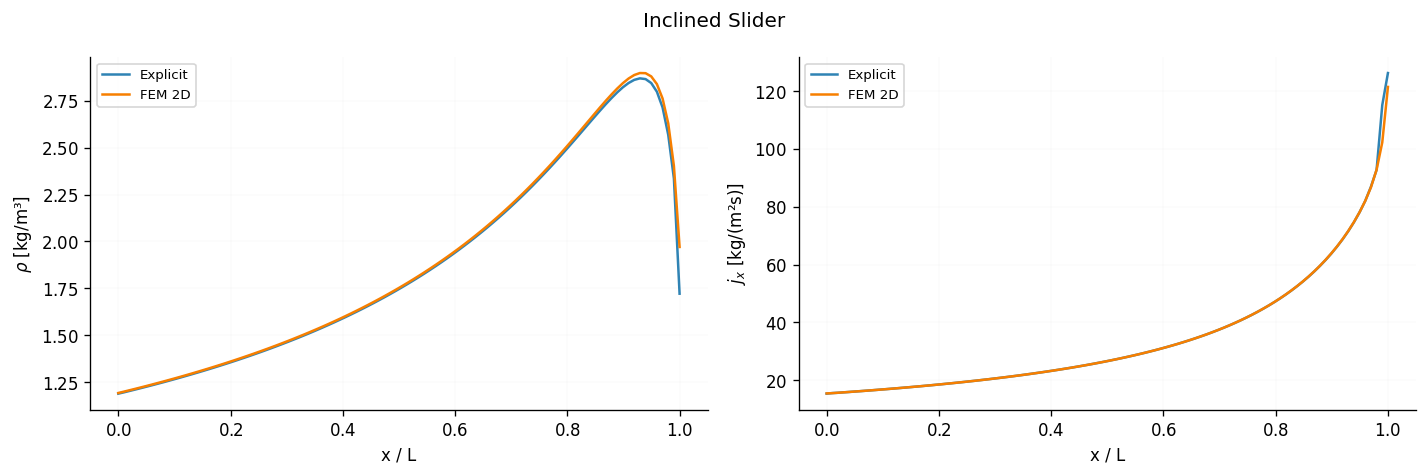

Timing:
  explicit   161.79 s
  fem_2d       3.98 s


In [6]:
plot_solver_comparison_rho_jx(results_inclined, 'Inclined Slider')
print_timing(results_inclined)

## Journal Bearing (Oil, DH EOS)

Cosine gap profile with fully periodic BC.

<img src="./figures/Geometry_JournalBearing.png"
     alt="Journal bearing geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/journal_bearing.yaml)**

In [7]:
template = load_template('journal_bearing')
results_journal = run_all_solvers(template, 
                                   explicit_overrides={'dt': 1e-10, 'adaptive': 1, 'CFL': 0.1})

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/journal_bearing_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - dx                       : 1e-05
  - Lx                       : 0.001
  - Ny                       : 1
  - dy                       : 1e-05
  - Ly                       : 1e-05
  - dim                      : 1
  - bc_xW                    : ['P', 'P', 'P']
  - bc_xE                    : ['P', 'P', 'P']
  - bc_yS                    : ['P', 'P', 'P']
  - bc_yN                    : ['P', 'P', 'P']
- geometry:
  - U_bot                    

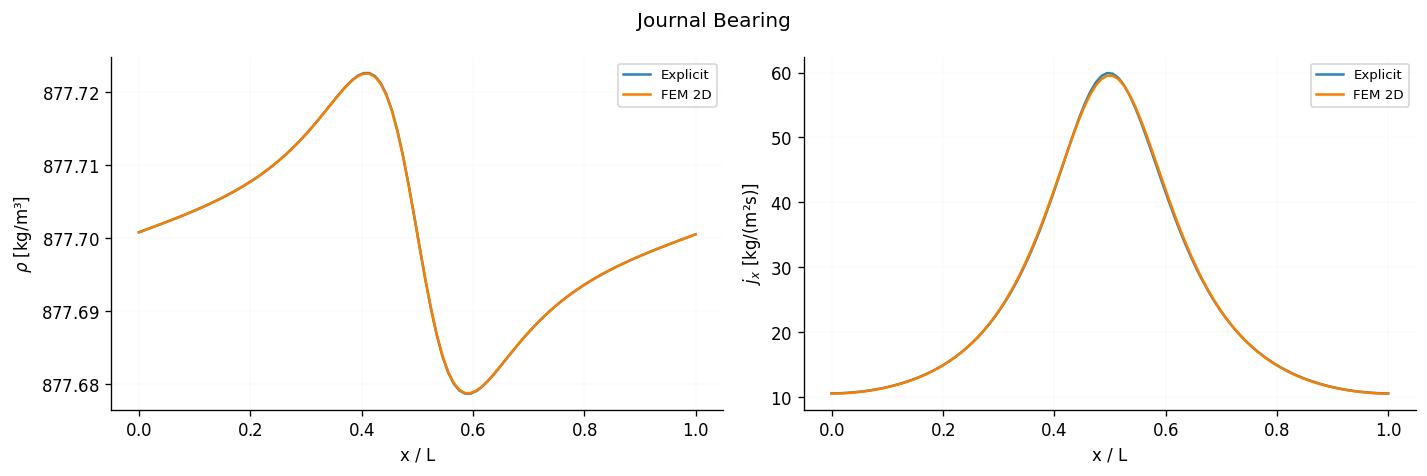

Timing:
  explicit   230.76 s
  fem_2d       2.88 s


In [8]:
plot_solver_comparison_rho_jx(results_journal, 'Journal Bearing')
print_timing(results_journal)

## Parabolic Slider (Oil, DH EOS)

Parabolic gap profile with Dirichlet density BC.

<img src="./figures/Geometry_ParabolicSlider13.png"
     alt="Parabolic slider geometry"
     width="250">

$\rightarrow$ **[YAML File](../../tests/configs/parabolic_slider.yaml)**

In [13]:
template = load_template('parabolic_slider')
results_parabolic = run_all_solvers(template, 
                                     explicit_overrides={'dt': 1e-10, 'adaptive': 1, 'CFL': 0.45},
                                     rho_bc=850.0)

*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/parabolic_slider_explicit
  - write_freq               : 1000
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 256
  - Lx                       : 0.0762
  - dx                       : 0.00029765625
  - Ny                       : 1
  - Ly                       : 0.004
  - dy                       : 0.004
  - dim                      : 1
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_D_val              : 850.0
  - bc_xE_D_val              : 850.0
  - bc_yS                    : ['P', 'P', 'P']
  - 

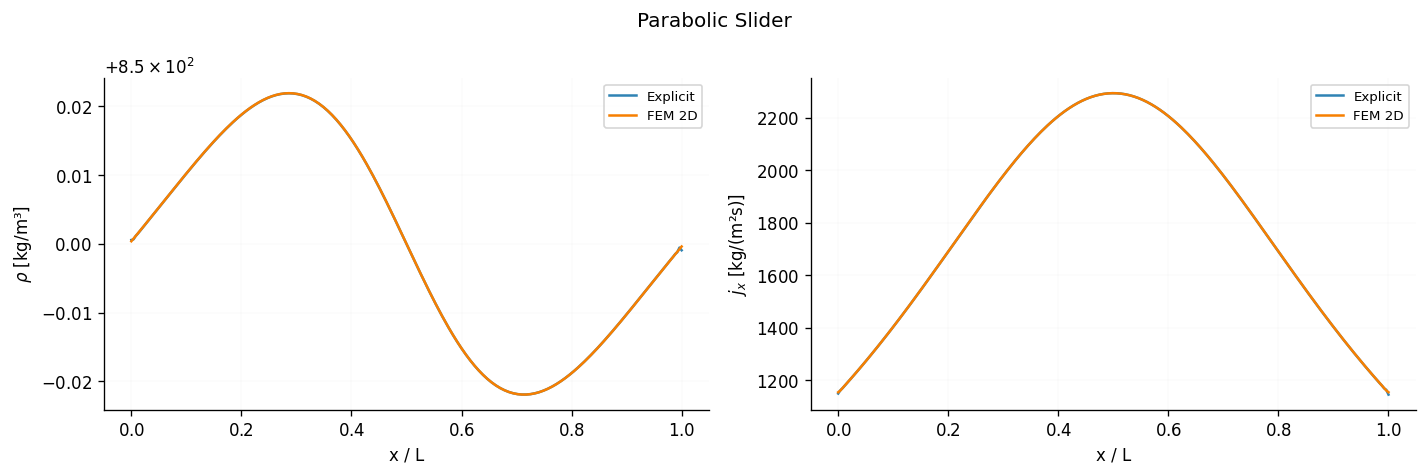

Timing:
  explicit   132.06 s
  fem_2d      11.50 s


In [14]:
plot_solver_comparison_rho_jx(results_parabolic, 'Parabolic Slider')
print_timing(results_parabolic)